C:\Users\admin\AppData\Local\Temp\ipykernel_13056\2060338040.py:8: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  radar_image = imageio.imread(image_path)


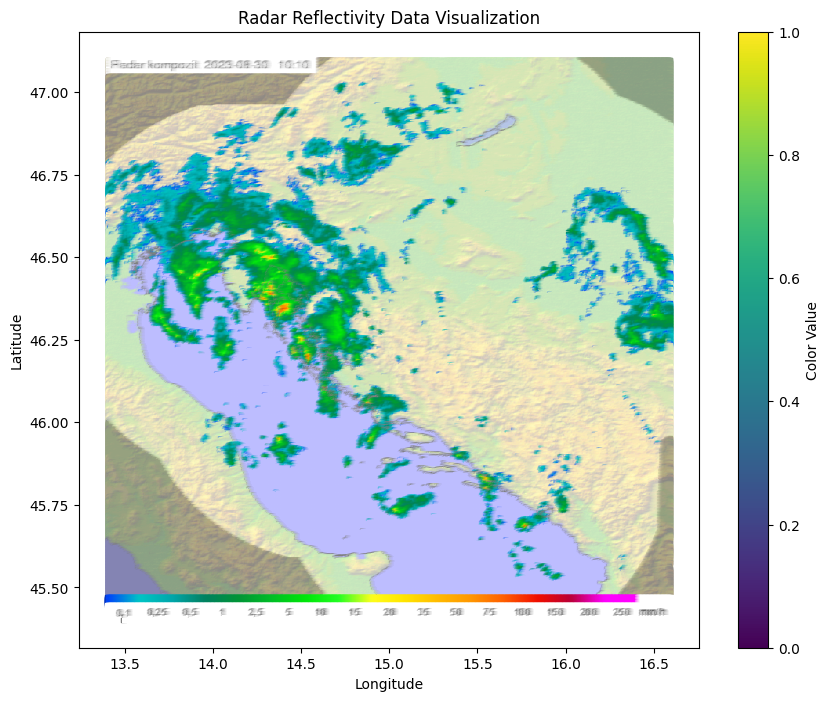

In [1]:
import numpy as np
import imageio
import csv
import matplotlib.pyplot as plt

# Load the radar image
image_path = '../45_hr_kompozit_download/data/2023/08/30/meteo_hr_radar_stat_kompozit_2023_08_30_10_18_26.jpg'
radar_image = imageio.imread(image_path)

# Define the bounding box coordinates for Slovenia and neighboring countries
min_lat = 45.4
max_lat = 47.1
min_lon = 13.4
max_lon = 16.6

# Get the dimensions of the radar image
height, width = radar_image.shape[:2]

# Calculate the latitude and longitude step sizes
lat_step = (max_lat - min_lat) / height
lon_step = (max_lon - min_lon) / width

# Initialize empty lists to store data
selected_latitudes = []
selected_longitudes = []
selected_values = []

# Loop through each pixel in the radar image and extract data
for y in range(height):
    for x in range(width):
        # Calculate latitude and longitude for the current pixel
        lat = max_lat - y * lat_step
        lon = min_lon + x * lon_step
        
        # Get the value at the current pixel
        value = radar_image[y, x]
        
        # Check if the value indicates radar reflectivity
        if np.any(value != [0, 0, 0]):
            selected_latitudes.append(lat)
            selected_longitudes.append(lon)
            selected_values.append(value)

# Convert lists to numpy arrays for better compatibility with matplotlib
selected_latitudes = np.array(selected_latitudes)
selected_longitudes = np.array(selected_longitudes)
selected_values = np.array(selected_values)

# Create a scatter plot with different colors based on selected values
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(selected_longitudes, selected_latitudes, c=selected_values / 255.0, marker='s', s=10)

# Set labels and title
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Radar Reflectivity Data Visualization')

# Create a colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Color Value')

# Show the plot
plt.show()
